In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.8 MB 8.2 MB/s eta 0:00:01
   ----------------- ---------------------- 4.2/9.8 MB 10.9 MB/s eta 0:00:01
   -------------------------- ------------- 6.6/9.8 MB 11.3 MB/s eta 0:00:01
   ----------------------------------- ---- 8.7/9.8 MB 10.7 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 9.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ------ --------------------------------- 2.1/12.3 MB 10.6 MB/s eta 0:00:01
   ------------ --------------------------- 3.9/12.3 MB 9.6 MB/s eta 0:00:01
   -------------------- ------------------- 6.3/12.3 MB 10.0 MB/s eta 0:00:01
   -------------------------- ------------- 8.1/12.3 MB 9.8 MB/s eta 0:00:01
   ------------------------------- ----


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

# Loading the dataset
df = pd.read_csv('winequality-red.csv')

# checking
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
# 1. Shape of the dataset i.e (Rows, Columns)
print("Dataset Shape:", df.shape)
print("-" * 40)

# 2. Get summary of columns, data types, and missing values
print("Dataset Info:")
df.info()
print("-" * 40)

# 3. Check exactly how many missing values are in each column
print("Missing Values per Column:")
print(df.isnull().sum())

Dataset Shape: (1596, 12)
----------------------------------------
Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1596 entries, 0 to 1595
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1596 non-null   float64
 1   volatile acidity      1596 non-null   float64
 2   citric acid           1596 non-null   float64
 3   residual sugar        1596 non-null   float64
 4   chlorides             1596 non-null   float64
 5   free sulfur dioxide   1596 non-null   float64
 6   total sulfur dioxide  1596 non-null   float64
 7   density               1596 non-null   float64
 8   pH                    1596 non-null   float64
 9   sulphates             1596 non-null   float64
 10  alcohol               1596 non-null   float64
 11  quality               1596 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 149.8 KB
----------------------------------------
Missing Values 

Matplotlib is building the font cache; this may take a moment.


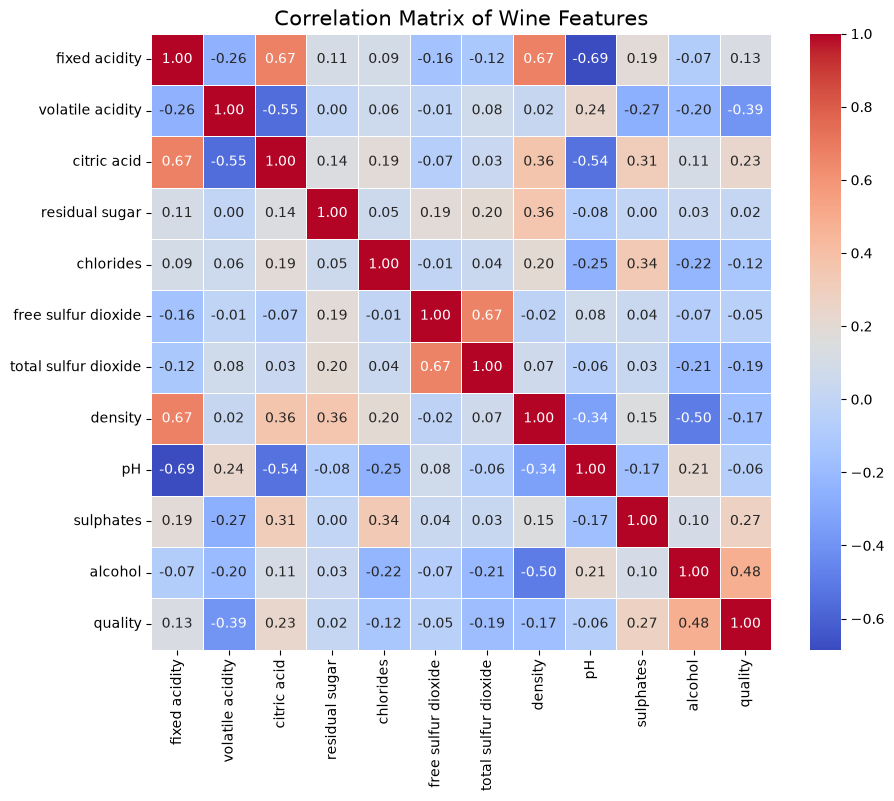

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the size of the plot
plt.figure(figsize=(10, 8))

# Create a heatmap of the correlations between columns
# 'annot=True' displays the actual correlation numbers inside the squares
# 'cmap='coolwarm'' makes positive correlations red and negative correlations blue
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)

# Title
plt.title('Correlation Matrix of Wine Features', fontsize=15)

# Display
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Convert quality scores into binary classes: 1 (Good) if quality >= 6, else 0 (Bad)
df['good_quality'] = [1 if x >= 6 else 0 for x in df['quality']]

# 2. Separate our features (X) from our target variable (y)
# We drop both 'quality' and 'good_quality' from X so the model doesn't cheat
X = df.drop(['quality', 'good_quality'], axis=1)
y = df['good_quality']

# 3. Split the data: 80% for training the model, 20% for testing it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scale the features so they all have a similar range (helps Logistic Regression perform better)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data split and scaled successfully!")
print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")

Data split and scaled successfully!
Training samples: 1276, Testing samples: 320


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# STEP 1: Initialize the Logistic Regression model
# I am using max_iter=1000 to give the model enough time to find the best solution
log_model = LogisticRegression(max_iter=1000)

# STEP 2: Train the model using our scaled training data
# This is where the model learns the relationship between chemical features and wine quality
log_model.fit(X_train_scaled, y_train)

# STEP 3: Make predictions on the unseen test data
log_predictions = log_model.predict(X_test_scaled)

# STEP 4: Calculate how accurate our model's predictions are
log_accuracy = accuracy_score(y_test, log_predictions)

# STEP 5: Print the final results nicely for my project report
print("--- LOGISTIC REGRESSION RESULTS ---")
print(f"Accuracy Score: {log_accuracy * 100:.2f}%")
print("\nDetailed Classification Report:")
print(classification_report(y_test, log_predictions))

--- LOGISTIC REGRESSION RESULTS ---
Accuracy Score: 70.94%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.72      0.71       158
           1       0.72      0.70      0.71       162

    accuracy                           0.71       320
   macro avg       0.71      0.71      0.71       320
weighted avg       0.71      0.71      0.71       320



In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# STEP 1: Initialize the Random Forest Classifier
# I am setting n_estimators=100, which means the model will build 100 decision trees
# random_state=42 ensures that my results stay consistent every time I run this cell
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# STEP 2: Train the model on our scaled training data
# The forest learns by looking at different patterns across all 100 trees
rf_model.fit(X_train_scaled, y_train)

# STEP 3: Test the model by predicting quality on the test dataset
rf_predictions = rf_model.predict(X_test_scaled)

# STEP 4: Calculate the accuracy of the Random Forest model
rf_accuracy = accuracy_score(y_test, rf_predictions)

# STEP 5: Print out the final comparison metrics for my project analysis
print("--- RANDOM FOREST RESULTS ---")
print(f"Accuracy Score: {rf_accuracy * 100:.2f}%")
print("\nDetailed Classification Report:")
print(classification_report(y_test, rf_predictions))

--- RANDOM FOREST RESULTS ---
Accuracy Score: 79.69%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.77      0.79       158
           1       0.79      0.82      0.80       162

    accuracy                           0.80       320
   macro avg       0.80      0.80      0.80       320
weighted avg       0.80      0.80      0.80       320

